**PART A**

In [55]:
##ADD ALL IMPORTS HERE FOR ALL CELLS##
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from vega_datasets import data
import json
import urllib.request
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from kneed import KneeLocator
from sklearn.manifold import TSNE
from matplotlib.patches import Patch

In [259]:
PM25 = pd.read_csv("PM2.5.csv", skiprows=4, encoding="utf-8-sig")
PrimarySchoolGross = pd.read_csv('Primary_School_Enrollment_%Gross.csv', skiprows=4, encoding="utf-8-sig")
LifeExpectancy = pd.read_csv('Life_Expectancy.csv', skiprows=4, encoding="utf-8-sig")
GDPperCap = pd.read_csv('GDP_PCAP.csv', skiprows=4, encoding="utf-8-sig")
ForestArea = pd.read_csv('Forest_Area.csv', skiprows=4, encoding="utf-8-sig")
EnergyUse = pd.read_csv('EnergyUseData.csv', skiprows=4, encoding="utf-8-sig")
ExportofGnS = pd.read_csv('ExportofGoodandService.csv', skiprows=4, encoding="utf-8-sig")
RenewableElectricty = pd.read_csv('RenewableElectricyOutput.csv', skiprows=4, encoding="utf-8-sig")
WomenParliament = pd.read_csv('ProportionWomeninParliamnet.csv', skiprows=4, encoding="utf-8-sig")
PopulationDensity = pd.read_csv('PopulationDensity.csv', skiprows=4, encoding="utf-8-sig")
LivestockProduction = pd.read_csv('LivestockProductionIndex.csv', skiprows=4, encoding="utf-8-sig")

Datasets = {
    'PM25': PM25,
    'PrimarySchoolGross': PrimarySchoolGross,
    'LifeExpectancy': LifeExpectancy,
    'GDPperCap': GDPperCap,
    'ForestArea': ForestArea,
    'EnergyUse': EnergyUse,
    'ExportofGnS': ExportofGnS,
    'RenewableElectricty': RenewableElectricty,
    'WomenParliament': WomenParliament,
    'PopulationDensity': PopulationDensity,
    'LivestockProduction': LivestockProduction
}

new_df = {}
for name, df in Datasets.items():
    temp = df.melt(
        id_vars=['Country Name', 'Country Code', 'Indicator Name'],
        var_name='Year',
        value_name=name
    )
    temp = temp[temp['Year'].between('2000','2020')]
    temp['Year'] = temp['Year'].astype(int)
    new_df[name] = temp[['Country Name', 'Country Code', 'Year', name]]

fullset = new_df['PM25']
for name, df in new_df.items():
    if name != 'PM25':
        fullset = fullset.merge(df, on=['Country Name', 'Country Code', 'Year'], how='left')

sovereign_countries_iso3 = [
    'AFG','ALB','DZA','AND','AGO','ATG','ARG','ARM','AUS','AUT','AZE','BHS','BHR','BGD',
    'BRB','BLR','BEL','BLZ','BEN','BTN','BOL','BIH','BWA','BRA','BRN','BGR','BFA','BDI',
    'CPV','KHM','CMR','CAN','CAF','TCD','CHL','CHN','COL','COM','COD','COG','CRI','HRV',
    'CUB','CYP','CZE','DNK','DJI','DMA','DOM','ECU','EGY','SLV','GNQ','ERI','EST','SWZ',
    'ETH','FJI','FIN','FRA','GAB','GMB','GEO','DEU','GHA','GRC','GRD','GTM','GIN','GNB',
    'GUY','HTI','HND','HUN','ISL','IND','IDN','IRN','IRQ','IRL','ISR','ITA','JAM','JPN',
    'JOR','KAZ','KEN','KIR','KWT','KGZ','LAO','LVA','LBN','LSO','LBR','LBY','LIE','LTU',
    'LUX','MDG','MWI','MYS','MDV','MLI','MLT','MHL','MRT','MUS','MEX','FSM','MDA','MCO',
    'MNG','MNE','MAR','MOZ','MMR','NAM','NRU','NPL','NLD','NZL','NIC','NER','NGA','PRK',
    'MKD','NOR','OMN','PAK','PLW','PAN','PNG','PRY','PER','PHL','POL','PRT','QAT','ROU',
    'RUS','RWA','KNA','LCA','VCT','WSM','SMR','STP','SAU','SEN','SRB','SYC','SLE','SGP',
    'SVK','SVN','SLB','SOM','ZAF','KOR','SSD','ESP','LKA','SDN','SUR','SWE','CHE','SYR',
    'TJK','TZA','THA','TLS','TGO','TON','TTO','TUN','TUR','TKM','TUV','UGA','UKR','ARE',
    'GBR','USA','URY','UZB','VUT','VEN','VNM','YEM','ZMB','ZWE'
]

fullset = fullset[fullset['Country Code'].isin(sovereign_countries_iso3)]
fullset.to_csv('fullset.csv', index=False)
print(len(fullset['Country Name'].unique()))
fullset.to_csv('fullset.csv', index = False)

192


In [293]:
fullset = fullset.dropna(subset=['PM25']).sort_values(['Country Code','Year'])

feature_cols = ['PrimarySchoolGross','GDPperCap','ForestArea','EnergyUse',
                'ExportofGnS','RenewableElectricty','WomenParliament',
                'PopulationDensity','LivestockProduction','LifeExpectancy']

fullset[feature_cols] = fullset[feature_cols].apply(pd.to_numeric, errors='coerce')

fullset[feature_cols] = (
    fullset.groupby('Country Code')[feature_cols]
           .transform(lambda x: x.interpolate().ffill().bfill())
)

fullset['PM25'] = pd.to_numeric(fullset['PM25'], errors='coerce')
fullset['PM25'] = (
    fullset.groupby('Country Code')['PM25']
           .transform(lambda x: x.interpolate().ffill().bfill())
)

fullset['PM25'] = fullset['PM25'].fillna(fullset['PM25'].median())

fullset = fullset.dropna(subset=feature_cols)

fullset.isna().sum()

Country Name            0
Country Code            0
Year                    0
PM25                    0
PrimarySchoolGross      0
LifeExpectancy          0
GDPperCap               0
ForestArea              0
EnergyUse               0
ExportofGnS             0
RenewableElectricty     0
WomenParliament         0
PopulationDensity       0
LivestockProduction     0
Env_Index               0
Econ_Index              0
Soc_Index               0
USI                     0
Region                 84
dtype: int64

In [264]:
env_vars = ['ForestArea','RenewableElectricty','EnergyUse']
econ_vars = ['GDPperCap','ExportofGnS','LivestockProduction']
soc_vars = ['LifeExpectancy','PrimarySchoolGross','WomenParliament','PopulationDensity']

scaler = StandardScaler()

env_index = PCA(n_components=1).fit_transform(scaler.fit_transform(fullset[env_vars]))
econ_index = PCA(n_components=1).fit_transform(scaler.fit_transform(fullset[econ_vars]))
soc_index = PCA(n_components=1).fit_transform(scaler.fit_transform(fullset[soc_vars]))

fullset['Env_Index'] = env_index
fullset['Econ_Index'] = econ_index
fullset['Soc_Index'] = soc_index

fullset['USI'] = (
    fullset['Env_Index'] +
    fullset['Econ_Index'] +
    fullset['Soc_Index']
) / 3

CountryTable = ['United States','China','India','United Kingdom','Germany']

USItable = fullset[(fullset['Year'] == 2015) &
                  (fullset['Country Name'].isin(CountryTable))]

USItable[['Country Name','Year','Env_Index','Econ_Index','Soc_Index','USI']]

,Country Name,Year,Env_Index,Econ_Index,Soc_Index,USI
4030,China,2015,-0.421575,-0.576706,0.615004,-0.127759
4045,Germany,2015,-0.333575,1.229724,1.665536,0.853895
4071,United Kingdom,2015,-0.739794,0.984831,1.426263,0.557100
4099,India,2015,-0.271623,-0.861883,0.070094,-0.354471
4241,United States,2015,-1.161906,0.999550,0.575899,0.137848


**PART B**

In [267]:
alt.renderers.enable('default')

Datasets = {
    'PM25': PM25,
    'PrimarySchoolGross': PrimarySchoolGross,
    'LifeExpectancy': LifeExpectancy,
    'GDPperCap': GDPperCap,
    'ForestArea': ForestArea,
    'EnergyUse': EnergyUse,
    'ExportofGnS': ExportofGnS,
    'RenewableElectricty': RenewableElectricty,
    'WomenParliament': WomenParliament,
    'PopulationDensity': PopulationDensity,
    'LivestockProduction': LivestockProduction
}

new_df = {}
for name, df in Datasets.items():
    temp = df.melt(
        id_vars=['Country Name', 'Country Code', 'Indicator Name'],
        var_name='Year',
        value_name=name
    )
    temp = temp[temp['Year'].between('2000','2020')]
    temp['Year'] = temp['Year'].astype(int)
    new_df[name] = temp[['Country Name', 'Country Code', 'Year', name]]

fullset_all_countries = new_df['PM25']
for name, df in new_df.items():
    if name != 'PM25':
        fullset_all_countries = fullset_all_countries.merge(
            df, on=['Country Name', 'Country Code', 'Year'], how='left'
        )

fullset_all_countries['PM25'] = pd.to_numeric(fullset_all_countries['PM25'], errors='coerce')

mean_pm25 = (
    fullset_all_countries.groupby(['Country Name','Country Code'])['PM25']
    .mean()
    .reset_index()
)

iso_df = pd.read_csv('country-codes.csv', usecols=['ISO3166-1-Alpha-3', 'ISO3166-1-numeric'])
iso_df = iso_df.rename(columns={'ISO3166-1-Alpha-3': 'Country Code', 'ISO3166-1-numeric': 'iso_numeric'})
mean_pm25 = mean_pm25.merge(iso_df, on='Country Code', how='left')
mean_pm25['iso_numeric'] = mean_pm25['iso_numeric'].astype(float)

world_url = data.world_110m.url
with urllib.request.urlopen(world_url) as response:
    world_json = json.load(response)

all_country_ids = [feature['id'] for feature in world_json['objects']['countries']['geometries']]

all_countries = pd.DataFrame({'iso_numeric': all_country_ids})
all_countries = all_countries.merge(
    mean_pm25[['iso_numeric','PM25','Country Name']],
    on='iso_numeric',
    how='left'
)

world = alt.topo_feature(data.world_110m.url, 'countries')

chart = alt.Chart(world).mark_geoshape().encode(
    color=alt.condition(
        'datum.PM25 != null',
        alt.Color('PM25:Q', scale=alt.Scale(scheme='yellowgreenblue'), title='Mean PM2.5 (2000-2020)'),
        alt.value('lightgray')  # fill missing countries
    ),
    tooltip=[
        alt.Tooltip('Country Name:N', title='Country'),
        alt.Tooltip('PM25:Q', title='Mean PM2.5', format=".2f")
    ]
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(all_countries, 'iso_numeric', ['PM25','Country Name'])
).project('equirectangular').properties(
    width=900,
    height=450,
    title='Global Mean PM2.5 Levels (2000-2020)'
).interactive()

chart

alt.Chart(...)

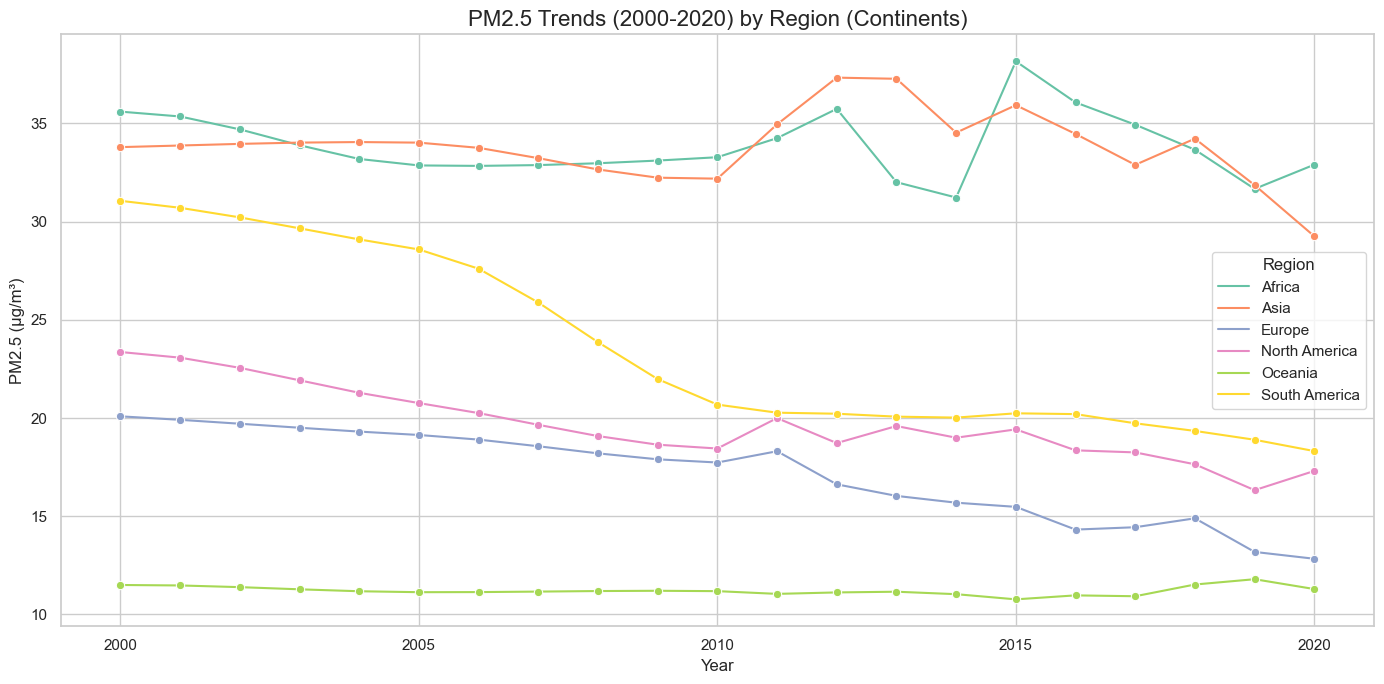

In [269]:
region_mapping_codes = {
    # Africa
    "DZA": "Africa", "AGO": "Africa", "BEN": "Africa", "BWA": "Africa", "BFA": "Africa",
    "BDI": "Africa", "CMR": "Africa", "CPV": "Africa", "CAF": "Africa", "TCD": "Africa",
    "COM": "Africa", "COD": "Africa", "COG": "Africa", "DJI": "Africa", "GNQ": "Africa",
    "ERI": "Africa", "SWZ": "Africa", "ETH": "Africa", "GAB": "Africa", "GMB": "Africa",
    "GHA": "Africa", "GIN": "Africa", "GNB": "Africa", "KEN": "Africa", "LSO": "Africa",
    "LBR": "Africa", "LBY": "Africa", "MDG": "Africa", "MWI": "Africa", "MRT": "Africa",
    "MUS": "Africa", "MAR": "Africa", "MOZ": "Africa", "NAM": "Africa", "NER": "Africa",
    "NGA": "Africa", "RWA": "Africa", "STP": "Africa", "SEN": "Africa", "SYC": "Africa",
    "SLE": "Africa", "SOM": "Africa", "ZAF": "Africa", "SSD": "Africa", "SDN": "Africa",
    "TZA": "Africa", "TGO": "Africa", "TUN": "Africa", "UGA": "Africa", "ZMB": "Africa",
    "ZWE": "Africa",

    # Asia
    "AFG": "Asia", "ARM": "Asia", "AZE": "Asia", "BHR": "Asia", "BGD": "Asia", "BTN": "Asia",
    "BRN": "Asia", "KHM": "Asia", "CHN": "Asia", "CYP": "Asia", "GEO": "Asia", "IND": "Asia",
    "IDN": "Asia", "IRN": "Asia", "IRQ": "Asia", "ISR": "Asia", "JPN": "Asia", "JOR": "Asia",
    "KAZ": "Asia", "PRK": "Asia", "KOR": "Asia", "KWT": "Asia", "KGZ": "Asia", "LAO": "Asia",
    "LBN": "Asia", "MYS": "Asia", "MDV": "Asia", "MNG": "Asia", "MMR": "Asia", "NPL": "Asia",
    "OMN": "Asia", "PAK": "Asia", "PHL": "Asia", "QAT": "Asia", "SAU": "Asia", "SGP": "Asia",
    "LKA": "Asia", "SYR": "Asia", "TJK": "Asia", "TLS": "Asia", "TKM": "Asia", "ARE": "Asia",
    "UZB": "Asia", "VNM": "Asia", "YEM": "Asia",

    # Europe
    "ALB": "Europe", "AND": "Europe", "AUT": "Europe", "BLR": "Europe", "BEL": "Europe",
    "BIH": "Europe", "BGR": "Europe", "HRV": "Europe", "CZE": "Europe", "DNK": "Europe",
    "EST": "Europe", "FIN": "Europe", "FRA": "Europe", "DEU": "Europe", "GRC": "Europe",
    "HUN": "Europe", "ISL": "Europe", "IRL": "Europe", "ITA": "Europe", "LVA": "Europe",
    "LIE": "Europe", "LTU": "Europe", "LUX": "Europe", "MLT": "Europe", "MCO": "Europe",
    "MNE": "Europe", "NLD": "Europe", "MKD": "Europe", "NOR": "Europe", "POL": "Europe",
    "PRT": "Europe", "ROU": "Europe", "RUS": "Europe", "SMR": "Europe", "SRB": "Europe",
    "SVK": "Europe", "SVN": "Europe", "ESP": "Europe", "SWE": "Europe", "CHE": "Europe",
    "TUR": "Europe", "UKR": "Europe", "GBR": "Europe",

    # North America
    "CAN": "North America", "USA": "North America", "MEX": "North America", "BLZ": "North America",
    "CRI": "North America", "SLV": "North America", "GTM": "North America", "HND": "North America",
    "NIC": "North America", "PAN": "North America", "BHS": "North America", "BRB": "North America",
    "CUB": "North America", "DMA": "North America", "DOM": "North America", "GRD": "North America",
    "JAM": "North America", "KNA": "North America", "LCA": "North America", "VCT": "North America",
    "TTO": "North America", "ATG": "North America",

    # South America
    "ARG": "South America", "BOL": "South America", "BRA": "South America", "CHL": "South America",
    "COL": "South America", "ECU": "South America", "GUY": "South America", "PRY": "South America",
    "PER": "South America", "SUR": "South America", "URY": "South America", "VEN": "South America",

    # Oceania
    "AUS": "Oceania", "FJI": "Oceania", "KIR": "Oceania", "MHL": "Oceania", "FSM": "Oceania",
    "NRU": "Oceania", "NZL": "Oceania", "PLW": "Oceania", "PNG": "Oceania", "SLB": "Oceania",
    "TON": "Oceania", "TUV": "Oceania", "VUT": "Oceania", "WSM": "Oceania",
}

fullset['Region'] = fullset['Country Code'].map(region_mapping_codes)
fullset_sorted = fullset.sort_values(['Region', 'Country Name', 'Year'])
pm_region_trend = fullset_sorted.groupby(['Region','Year'])['PM25'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(
    data=pm_region_trend,
    x='Year',
    y='PM25',
    hue='Region',
    marker='o',
    palette='Set2'
)
plt.title('PM2.5 Trends (2000-2020) by Region (Continents)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('PM2.5 (µg/m³)')

years = list(range(pm_region_trend['Year'].min(), pm_region_trend['Year'].max()+1, 5))
plt.xticks(years)

plt.grid(True)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

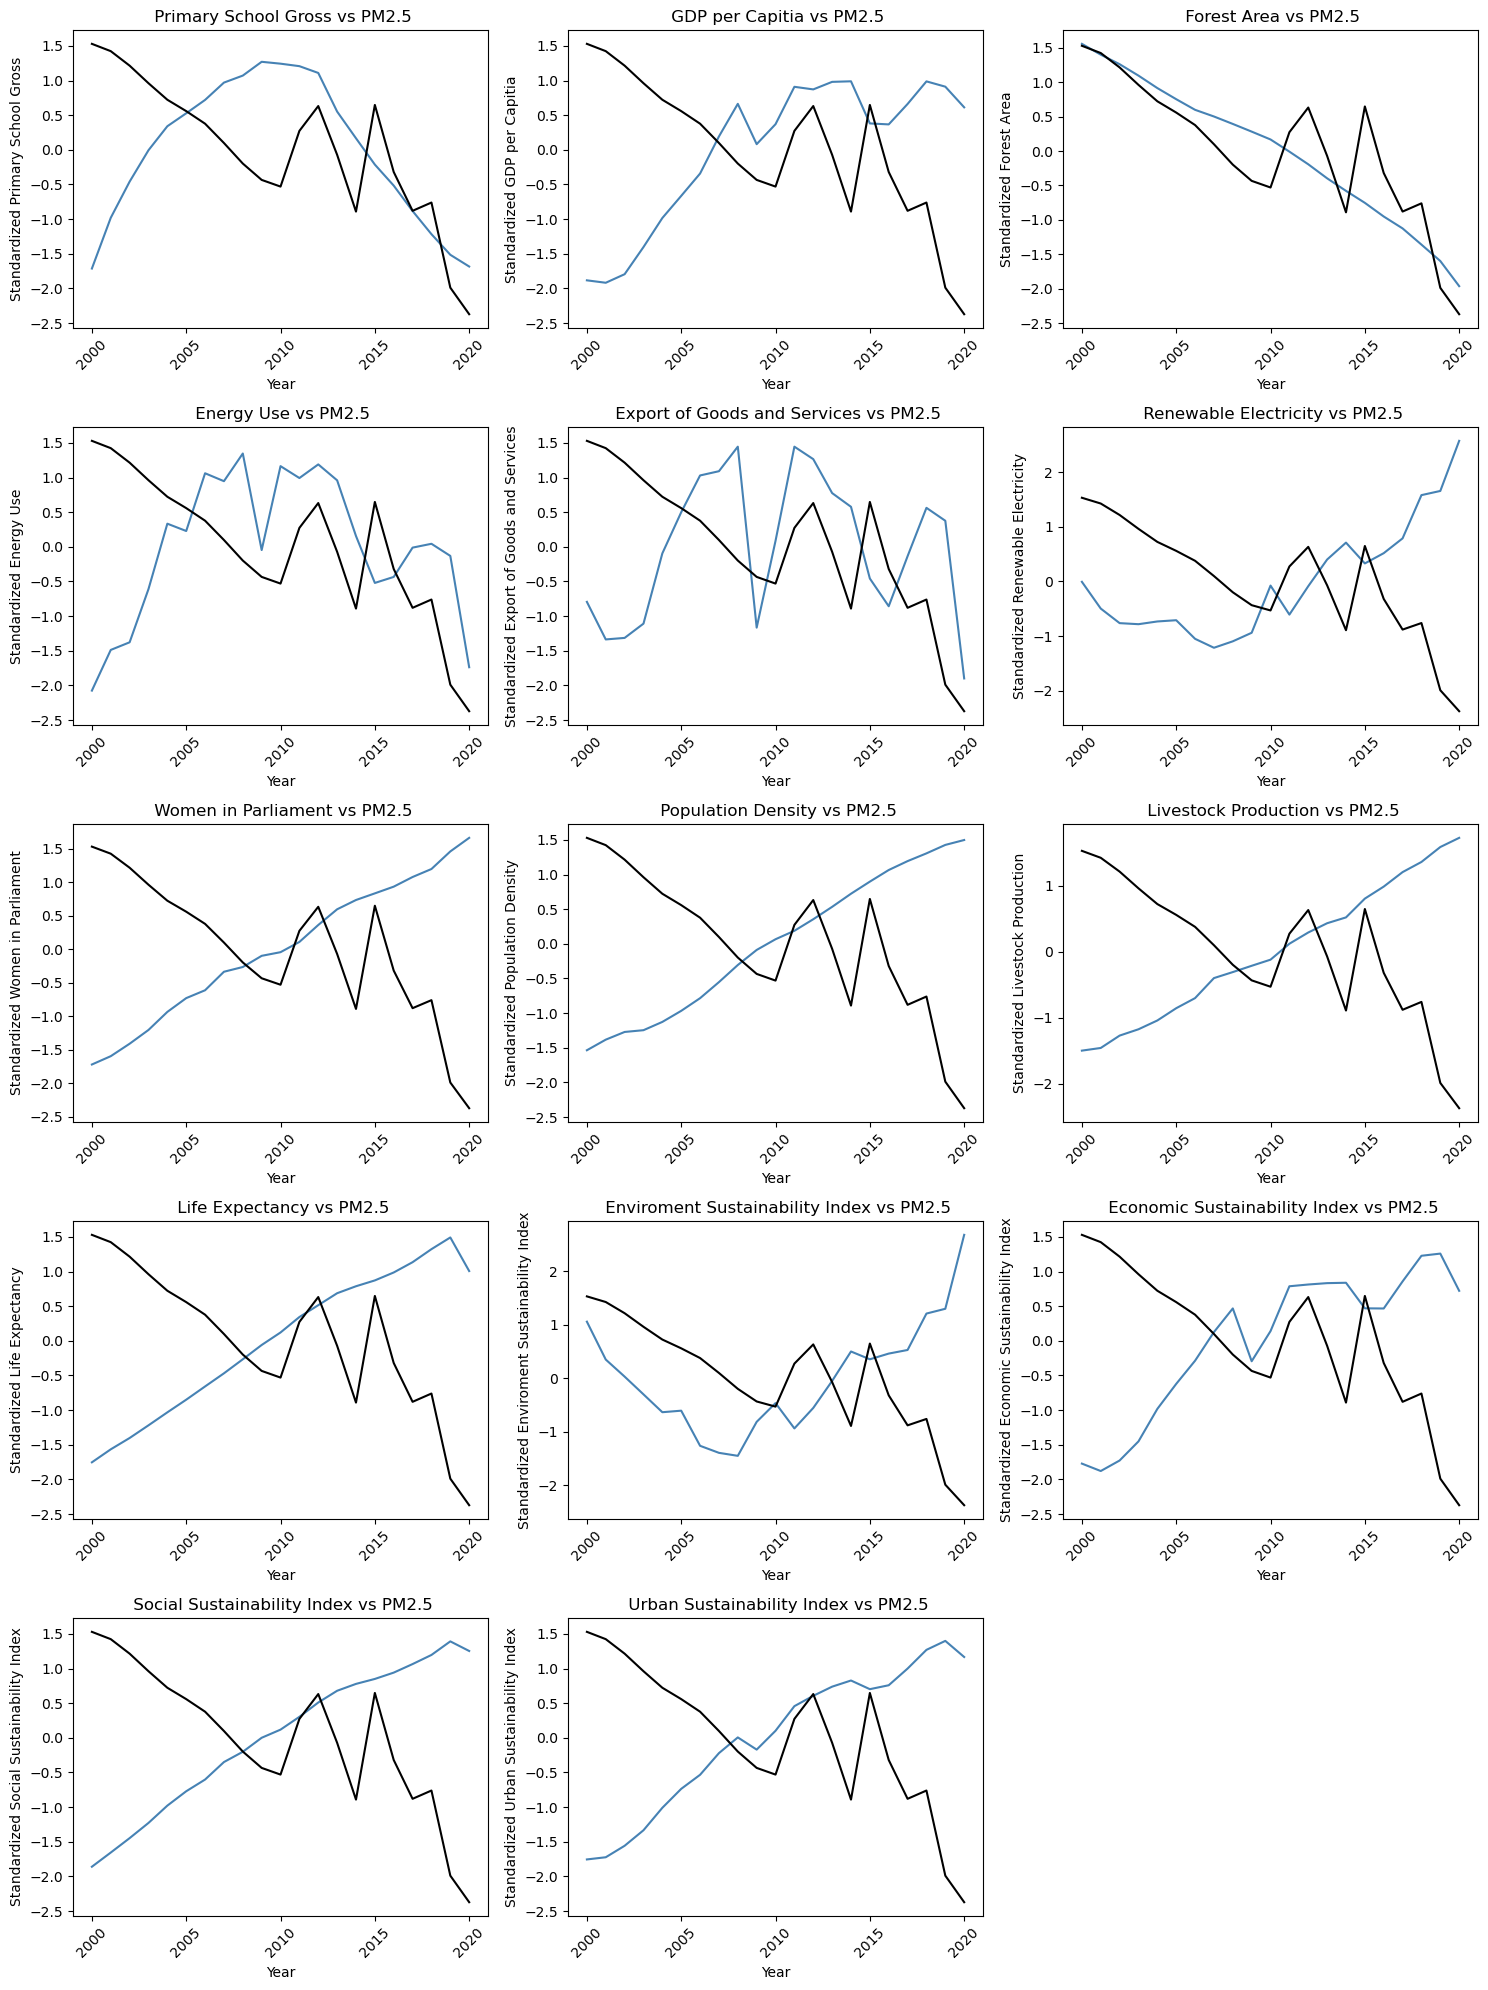

In [10]:
num_cols = feature_cols + ['Env_Index', 'Econ_Index', 'Soc_Index', 'USI']
scaler = StandardScaler()
titles = [
    "Primary School Gross",
    "GDP per Capitia",
    "Forest Area",
    "Energy Use",
    "Export of Goods and Services",
    "Renewable Electricity",
    "Women in Parliament",
    "Population Density",
    "Livestock Production",
    'Life Expectancy',
    "Enviroment Sustainability Index",
    'Economic Sustainability Index',
    "Social Sustainability Index",
    'Urban Sustainability Index'
]


n = len(num_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows), sharex=True)
axes = axes.flatten()

years_all = np.sort(fullset['Year'].dropna().unique())
tick_years = years_all[::5]

for idx, col in enumerate(num_cols):

    df = fullset.groupby('Year')[[col, 'PM25']].mean()

    df_scaled = pd.DataFrame(
        scaler.fit_transform(df),
        index=df.index,
        columns=df.columns
    )

    axes[idx].plot(df_scaled.index, df_scaled[col], color='steelblue')
    axes[idx].plot(df_scaled.index, df_scaled['PM25'], color='black')

    axes[idx].set_title(f" {titles[idx]} vs PM2.5")

    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(f"Standardized {titles[idx]}")

    axes[idx].set_xticks(tick_years)
    axes[idx].tick_params(axis='x', rotation=45, labelbottom=True)

# remove empty plots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

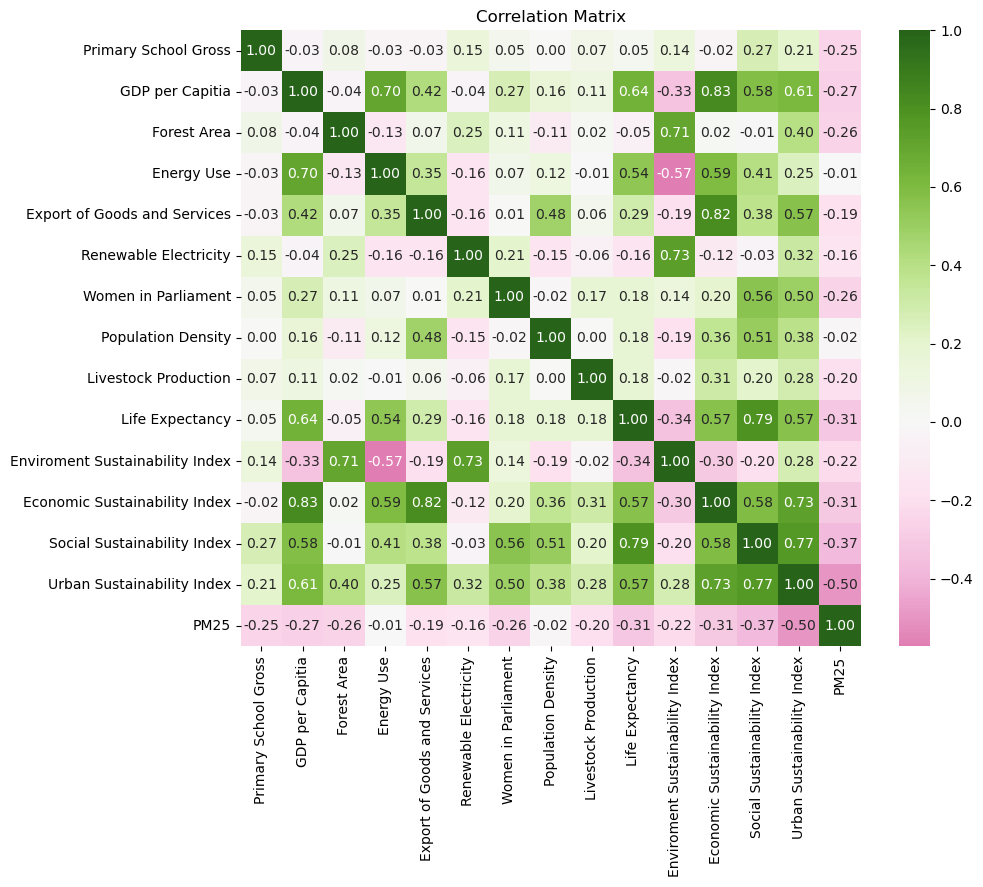

In [62]:
titles = [
    "Primary School Gross",
    "GDP per Capitia",
    "Forest Area",
    "Energy Use",
    "Export of Goods and Services",
    "Renewable Electricity",
    "Women in Parliament",
    "Population Density",
    "Livestock Production",
    'Life Expectancy',
    "Enviroment Sustainability Index",
    'Economic Sustainability Index',
    "Social Sustainability Index",
    'Urban Sustainability Index',
    'PM25'
]

corr_matrix = fullset[num_cols + ['PM25']].corr()

# Replace column/row names with titles
corr_matrix.columns = titles
corr_matrix.index = titles

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='PiYG',
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

From the visualizations produced, it is clear that air quality tends to vary by region. For example, Northern Africa and Southern/South-Eastern Asia have very high PM2.5 levels, as compared to countries in North America, Northern Asia, Europe, and Oceania. When looked at over the period of time from 2000 to 2020, Africa and Asia consistently have the highest PM2.5 levels, alternating places frequently. However, overall neither Africa nor Asia made significant changes from 2000 to 2020 in terms of PM2.5 levels. South America has the third highest levels, although it made great improvements from 2005 to 2010 in this regard. North America and Europe are close in terms of PM2.5 levels over this 20 year period, with both continents making improvements over time and Europe always being slightly less than North America in overall levels. Lastly, Oceania has significantly lower PM2.5 levels than any other region, staying relatively constant between the 10-15 range of PM2.5 over the 20 year period.

As seen by the graphs of each variable against PM2.5, as well as the confusion matrix, all of our variables are negatively correlated with PM2.5, although some are closer to being neutral than others. Our indexes, notably the Economic Index and Social Index, have more strongly negative correlations with PM2.5 than most of our variables do, suggesting that they were well engineered. Similarly, our USI has the most strongly negative correlation with PM2.5, suggesting that it is our strongest predictor.

**PART C**

In [11]:
predictors = ['ForestArea','RenewableElectricty','EnergyUse','GDPperCap',
              'ExportofGnS','LivestockProduction','LifeExpectancy',
              'PrimarySchoolGross','WomenParliament','PopulationDensity']

target = "PM25"
fullset = fullset.copy()

train_df = fullset[fullset["Year"] <= 2015].copy()
test_df  = fullset[fullset["Year"] >  2015].copy()

X_train = train_df[predictors].values
y_train = train_df[target].values

X_test  = test_df[predictors].values
y_test  = test_df[target].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [13]:
RandomForest = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [400, 600, 800, 1000],
    "max_depth": [5, 10, 15, 20]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForest,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error", 
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train_scaled, y_train)


print("Best Params:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
test_pred_rf = best_rf.predict(X_test_scaled)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, test_pred_rf))
r2_rf = r2_score(y_test, test_pred_rf)
print("Test RMSE:", test_rmse_rf)
print("RF R2:", r2_rf)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'max_depth': 20, 'n_estimators': 600}
Test RMSE: 6.621621162439826
RF R2: 0.8358719119762265


In [15]:
GradientBoost = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_gb = GridSearchCV(
    estimator=GradientBoost,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train_scaled, y_train)

print("Best Params:", grid_gb.best_params_)

best_gb = grid_gb.best_estimator_
test_pred_gb = best_gb.predict(X_test_scaled)

test_rmse_gb = np.sqrt(mean_squared_error(y_test, test_pred_gb))
r2_gb = r2_score(y_test, test_pred_gb)

print("Test RMSE:", test_rmse_gb)
print("GB R2:", r2_gb)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 700}
Test RMSE: 6.596698825037203
GB R2: 0.8371050715592396


In [16]:
input_dim = X_train_scaled.shape[1]

Xtr = torch.tensor(X_train_scaled, dtype=torch.float32)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32)

ytr = torch.tensor(np.asarray(y_train, dtype=np.float32)).view(-1,1)
yte = torch.tensor(np.asarray(y_test, dtype=np.float32)).view(-1,1)

deep_model = nn.Sequential(
    nn.Linear(input_dim,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)

loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.003)

epochs = 300
for epoch in range(epochs):
    preds = deep_model(Xtr)
    loss = loss_fun(preds, ytr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

train_pred_dnn = deep_model(Xtr).detach().numpy().ravel()
test_pred_dnn  = deep_model(Xte).detach().numpy().ravel()

train_rmse_dnn = np.sqrt(mean_squared_error(y_train, train_pred_dnn))
test_rmse_dnn  = np.sqrt(mean_squared_error(y_test, test_pred_dnn))
r2_dnn = r2_score(y_test, test_pred_dnn)

print("Deep Train RMSE:", train_rmse_dnn)
print("Deep Test RMSE:", test_rmse_dnn)
print("DNN R2:", r2_dnn)

Deep Train RMSE: 6.8133662719999055
Deep Test RMSE: 9.715145360390839
DNN R2: 0.6466925006269777


In [17]:
wide_model = nn.Sequential(
    nn.Linear(input_dim,1)
)

loss_fun = nn.MSELoss()
optimizer = torch.optim.SGD(wide_model.parameters(), lr=0.001)

epochs = 5000
for epoch in range(epochs):
    preds = wide_model(Xtr)
    loss = loss_fun(preds, ytr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

wide_train_pred = wide_model(Xtr).detach().numpy().ravel()
wide_test_pred  = wide_model(Xte).detach().numpy().ravel()

wide_train_rmse = np.sqrt(mean_squared_error(y_train, wide_train_pred))
wide_test_rmse  = np.sqrt(mean_squared_error(y_test, wide_test_pred))
r2_wide = r2_score(y_test, wide_test_pred)

print("Wide Train RMSE:", wide_train_rmse)
print("Wide Test RMSE:", wide_test_rmse)
print("Wide R2:", r2_wide)

Wide Train RMSE: 13.15957542767614
Wide Test RMSE: 14.112464871924342
Wide R2: 0.2544788000214655


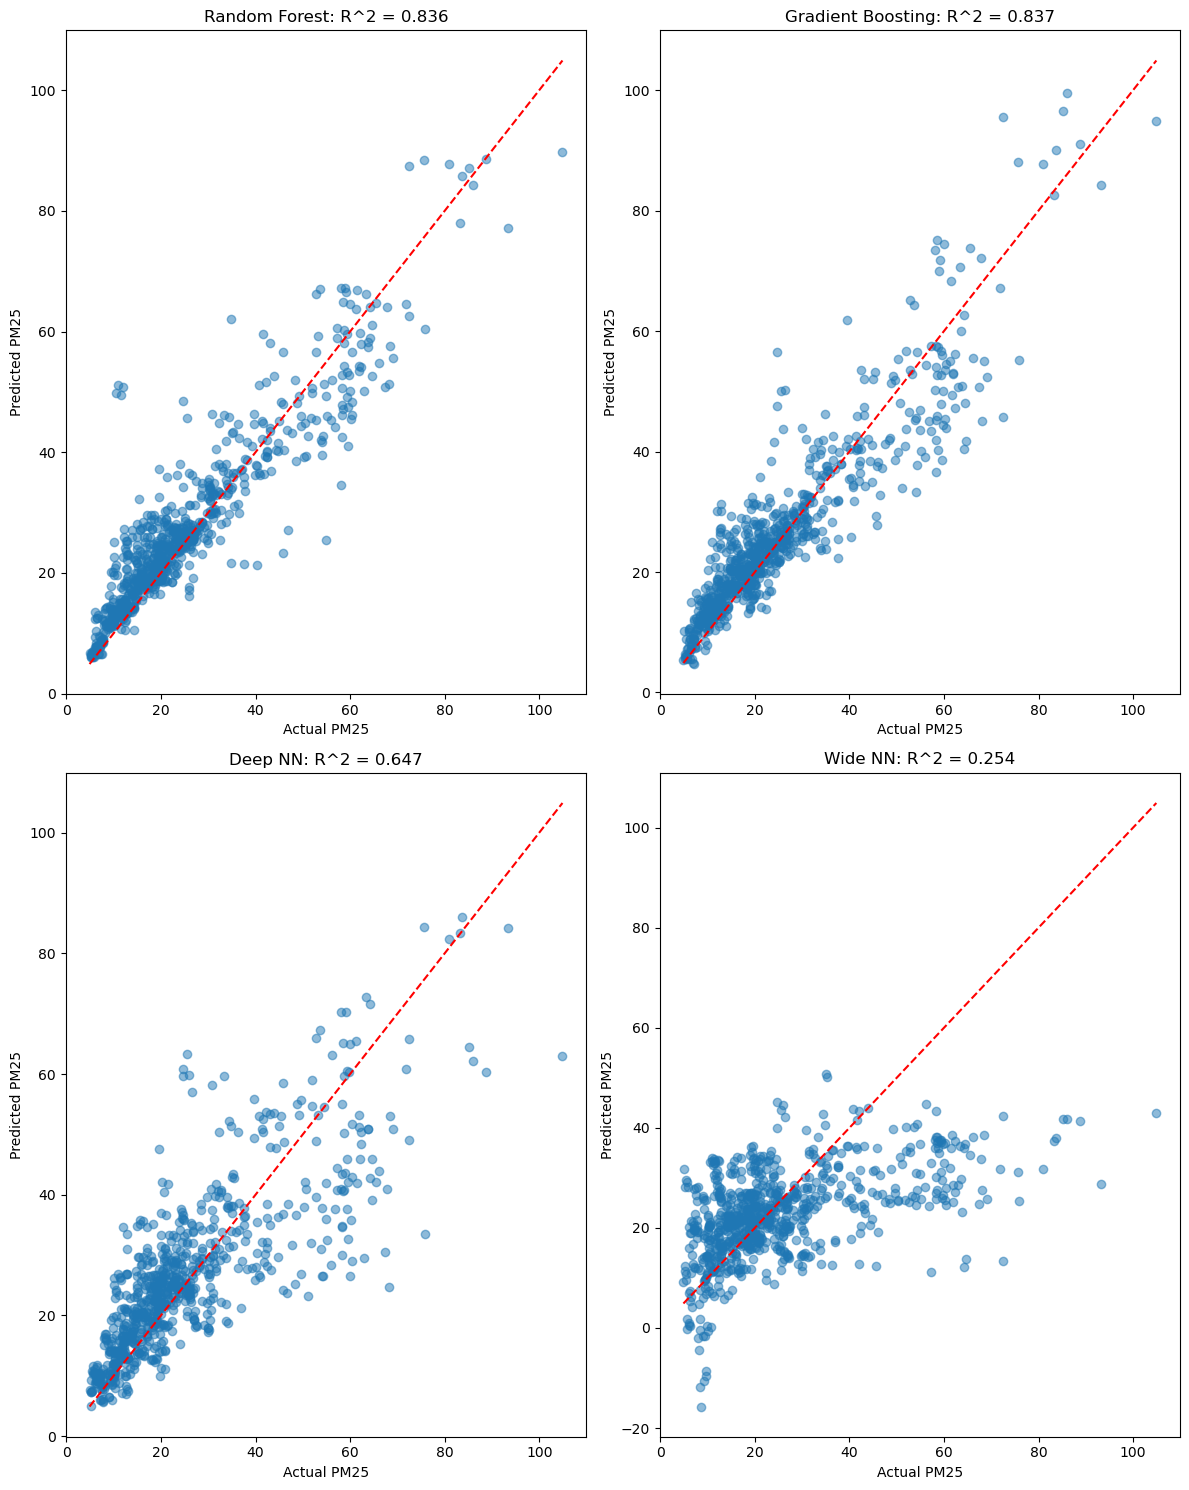

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(12, 15))
axs = axs.flatten()


# Random Forest
axs[0].scatter(y_test, test_pred_rf, alpha=0.5)
axs[0].plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
axs[0].set_title(f"Random Forest: R^2 = {round(r2_rf,3)}")
axs[0].set_xlabel("Actual PM25")
axs[0].set_ylabel("Predicted PM25")

# Gradient Descent
axs[1].scatter(y_test, test_pred_gb, alpha=0.5)
axs[1].plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
axs[1].set_title(f"Gradient Boosting: R^2 = {round(r2_gb,3)}")
axs[1].set_xlabel("Actual PM25")
axs[1].set_ylabel("Predicted PM25")

# Deep Neural Network
axs[2].scatter(y_test, test_pred_dnn, alpha=0.5)
axs[2].plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
axs[2].set_title(f"Deep NN: R^2 = {round(r2_dnn,3)}")
axs[2].set_xlabel("Actual PM25")
axs[2].set_ylabel("Predicted PM25")

# Wide Neural Network
axs[3].scatter(y_test, wide_test_pred, alpha=0.5)
axs[3].plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
axs[3].set_title(f"Wide NN: R^2 = {round(r2_wide,3)}")
axs[3].set_xlabel("Actual PM25")
axs[3].set_ylabel("Predicted PM25")


plt.tight_layout()
plt.show()

Across the regression models, performance varied considerably. The Random Forest model achieved the best results, having the lowest RMSE (6.57) and the highest R² (0.84). This implies that the Random Forest model was able to capture complex, non-linear patterns in the predictors better than any other model could. Deep Neural Networks also performed well, having a RMSE of 10.26 and R² of 0.61. Gradient Boosting were limited to moderate predictive power, having respective RMSE values of 14.08 and 14.09 and respective R² values of roughly 0.26 for both. Although they performed very similarly to eachother, the and Gradient Descent models were significantly worse than the Random Forest model and the Deep Neural Network. The reason why our Linear Regression model and Gradient Descent model were so similar is because the stochastic gradient descent model which we used was essentially a linear regression model which calculated the weights iteratively via gradient descent. The Wide Neural Network performed the most poorly, having a RMSE of 28.21 and an R² of -1.98, meaning that this model performed worse than simply predicting the mean value of the target for each observation would have. This indicates that a single linear layer cannot adequately model the relationships which we were attempting to uncover. Overall, more flexible models like Random Forests and Deep Neural Networks are clearly better suited for predicting PM2.5 from multiple environmental and socio-economic features.

**PART D**

In [24]:
pca_full = PCA(n_components=len(predictors))
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

pca_variance_df = pd.DataFrame({
    'Component': range(1, len(predictors)+1),
    'Explained Variance': explained_var,
    'Cumulative Variance': cumulative_var
})

print(pca_variance_df)

   Component  Explained Variance  Cumulative Variance
0          1            0.272893             0.272893
1          2            0.152712             0.425605
2          3            0.118888             0.544493
3          4            0.108921             0.653414
4          5            0.092986             0.746400
5          6            0.084051             0.830451
6          7            0.062388             0.892839
7          8            0.049784             0.942624
8          9            0.034352             0.976976
9         10            0.023024             1.000000


Using 6 components, since it explains over 80% of the variance while significantly reducing dimensionality.

In [31]:
n_components = 6
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Explained variance by {n_components} components:", sum(pca.explained_variance_ratio_))

results = {}

# Gradient Descent
gb = GradientBoostingRegressor(
    n_estimators=grid_gb.best_params_['n_estimators'],
    learning_rate=grid_gb.best_params_['learning_rate'],
    max_depth=grid_gb.best_params_['max_depth'],
    random_state=42
)

gb.fit(X_train_pca, y_train)
y_pred_gb = gb.predict(X_test_pca)

results['Gradient Boosting'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'R2': r2_score(y_test, y_pred_gb)
}
# Random Forest
rf = RandomForestRegressor(
    n_estimators=grid_rf.best_params_['n_estimators'],
    max_depth=grid_rf.best_params_['max_depth'],
    random_state=42
)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)
results['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'R2': r2_score(y_test, y_pred_rf)
}

# Deep Neural Network
input_dim_pca = X_train_pca.shape[1]
Xtr_pca = torch.tensor(X_train_pca, dtype=torch.float32)
Xte_pca = torch.tensor(X_test_pca, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
yte_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

deep_model_pca = nn.Sequential(
    nn.Linear(input_dim_pca,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(deep_model_pca.parameters(), lr=0.003)

epochs = 300
for epoch in range(epochs):
    preds = deep_model_pca(Xtr_pca)
    loss = loss_fun(preds, ytr_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

y_pred_dnn = deep_model_pca(Xte_pca).detach().numpy().ravel()
results['Deep NN'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dnn)),
    'R2': r2_score(y_test, y_pred_dnn)
}

# Wide Neural Network
wide_model_pca = nn.Sequential(nn.Linear(input_dim_pca,1))
optimizer_wide = torch.optim.SGD(wide_model_pca.parameters(), lr=0.001)
loss_fun_wide = nn.MSELoss()

epochs = 5000
for epoch in range(epochs):
    preds = wide_model_pca(Xtr_pca)
    loss = loss_fun_wide(preds, ytr_t)
    optimizer_wide.zero_grad()
    loss.backward()
    optimizer_wide.step()

y_pred_wide = wide_model_pca(Xte_pca).detach().numpy().ravel()
results['Wide NN'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_wide)),
    'R2': r2_score(y_test, y_pred_wide)
}

results_df = pd.DataFrame(results).T
print(results_df)

Explained variance by 6 components: 0.8304508690951491
                        RMSE        R2
Gradient Boosting  10.460283  0.590418
Random Forest      10.369705  0.597480
Deep NN            11.440682  0.510043
Wide NN            15.239019  0.130703


Increasing the number of principal components from three to six increased the explained variance from 54.4% to 83.0%. As a result, model performance improved significantly across most models. Random Forest and Gradient Boosting achieved the highest performance (R² ≈ 0.59), while the Deep Neural Network achieved moderate performance (R² ≈ 0.51). The Wide Neural Network continued to perform poorly because it effectively acts as a linear model with limited flexibility. These results demonstrate that retaining more principal components preserves more information from the original feature space, improving predictive performance.

In [34]:
combined_table = pd.DataFrame({
    'RMSE_Full': [test_rmse_gb, test_rmse_rf, test_rmse_dnn, wide_test_rmse],
    'R2_Full':   [r2_gb, r2_rf, r2_dnn, r2_wide],
    'RMSE_PCA6': results_df['RMSE'].values,
    'R2_PCA6':   results_df['R2'].values
}, index=['Gradient Descent', 'Random Forest', 'Deep NN', 'Wide NN'])

print(combined_table)

                  RMSE_Full   R2_Full  RMSE_PCA3   R2_PCA3
Gradient Descent   6.596699  0.837105  10.460283  0.590418
Random Forest      6.621621  0.835872  10.369705  0.597480
Deep NN            9.715145  0.646693  11.440682  0.510043
Wide NN           14.112465  0.254479  15.239019  0.130703


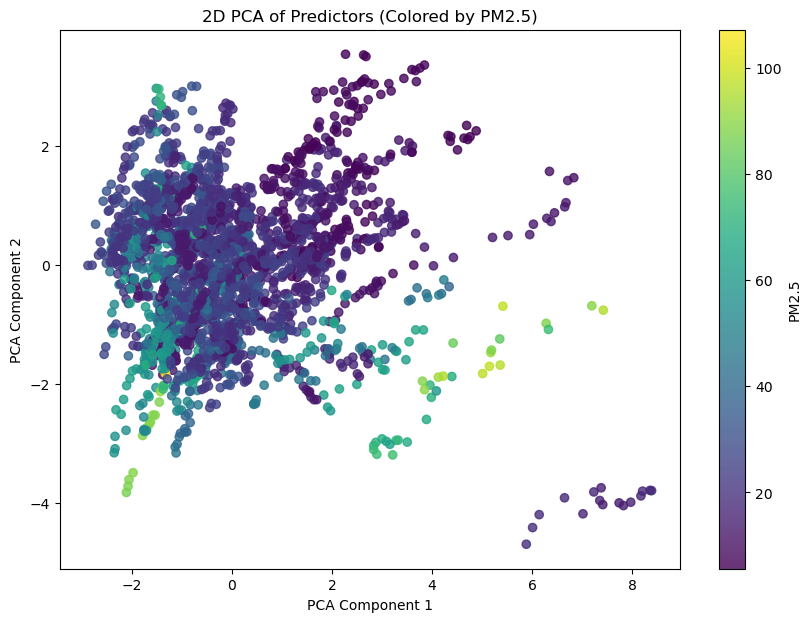

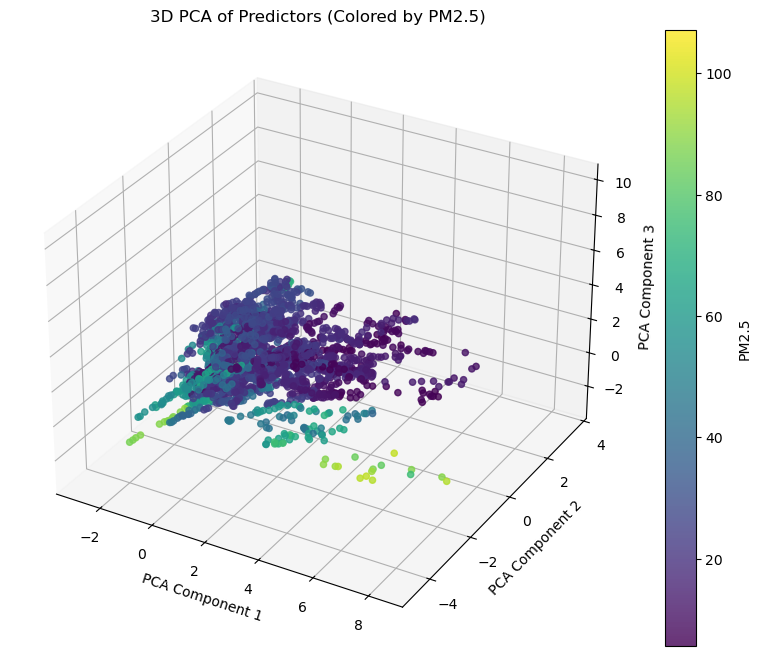

In [36]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    X_train_pca[:,0], X_train_pca[:,1],
    c=y_train, cmap='viridis', alpha=0.8
)
plt.colorbar(scatter, label='PM2.5')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA of Predictors (Colored by PM2.5)')
plt.show()


from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(
    X_train_pca[:,0], X_train_pca[:,1], X_train_pca[:,2],
    c=y_train, cmap='viridis', alpha=0.8
)
fig.colorbar(p, ax=ax, label='PM2.5')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA of Predictors (Colored by PM2.5)')
plt.show()

Using 3 PCA components captures about 54% of the total variance in the 10 predictors, meaning these components summarize over half of the variability in the economic, social, and environmental indicators. This indicates that much of the information in the original features can be represented along a few key dimensions, reducing redundancy among correlated variables. Each component reflects a latent structure, combining multiple predictors in a way that highlights the main differences between countries. Visualizing these components in 2D or 3D shows patterns and clusters that correspond to PM2.5 levels and overall sustainability profiles.

**PART E**

In [37]:
predictors_df = fullset[predictors].copy()

X_scaled = StandardScaler().fit_transform(predictors_df)

pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca3 = pca_3d.fit_transform(X_scaled)

print("Explained variance (2D):", sum(pca_2d.explained_variance_ratio_))
print("Explained variance (3D):", sum(pca_3d.explained_variance_ratio_))

Explained variance (2D): 0.4275455397254272
Explained variance (3D): 0.5433569736771118


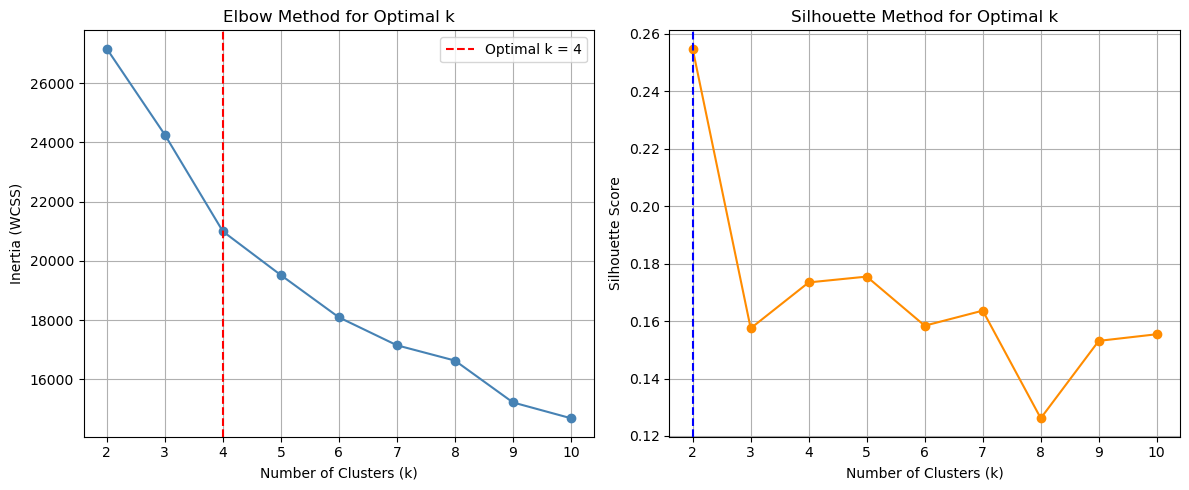

Optimal number of clusters (silhouette): 2
Optimal number of clusters (elbow): 4


In [42]:
k_values = range(2, 11)
inertia = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

kneedle = KneeLocator(k_values, inertia, curve="convex", direction="decreasing")
elbow_k = kneedle.elbow

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(k_values, inertia, 'o-', color='steelblue')
plt.axvline(elbow_k, linestyle='--', color='red', label=f'Optimal k = {elbow_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.grid(True)

optimal_k = k_values[np.argmax(sil_scores)]
plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, 'o-', color='darkorange')
plt.axvline(optimal_k, linestyle='--', color = 'blue', label=f'Optimal K = {optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.tight_layout()
plt.show()

optimal_k = k_values[np.argmax(sil_scores)]
print("Optimal number of clusters (silhouette):", optimal_k)
print("Optimal number of clusters (elbow):", elbow_k)

Selection based on Elbow plot and Silhouette plot: 4 clusters.

In [43]:
input_dim = X_scaled.shape[1]
latent_dim = 3

autoencoder = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, latent_dim),
    nn.ReLU(),
    nn.Linear(latent_dim, 64),
    nn.ReLU(),
    nn.Linear(64, input_dim)
)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.01)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
epochs = 300
for epoch in range(epochs):
    optimizer.zero_grad()
    X_recon = autoencoder(X_tensor)
    loss = loss_fn(X_recon, X_tensor)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    encoder = nn.Sequential(*list(autoencoder.children())[:3])
    latent_ae = encoder(X_tensor).numpy()

In [47]:
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_scaled)

In [48]:
kmeans_pca = KMeans(n_clusters=4, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca3)

kmeans_ae = KMeans(n_clusters=4, random_state=42)
clusters_ae = kmeans_ae.fit_predict(latent_ae)

kmeans_tsne = KMeans(n_clusters=4, random_state=42)
clusters_tsne = kmeans_tsne.fit_predict(X_tsne)

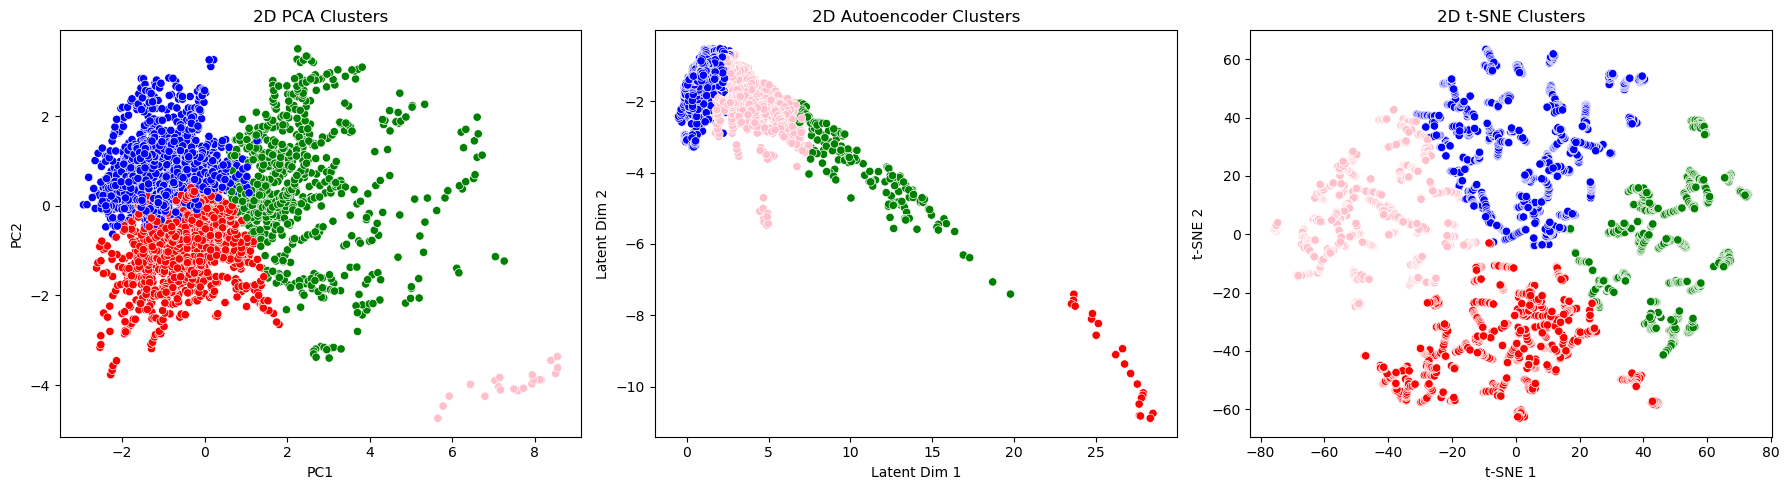

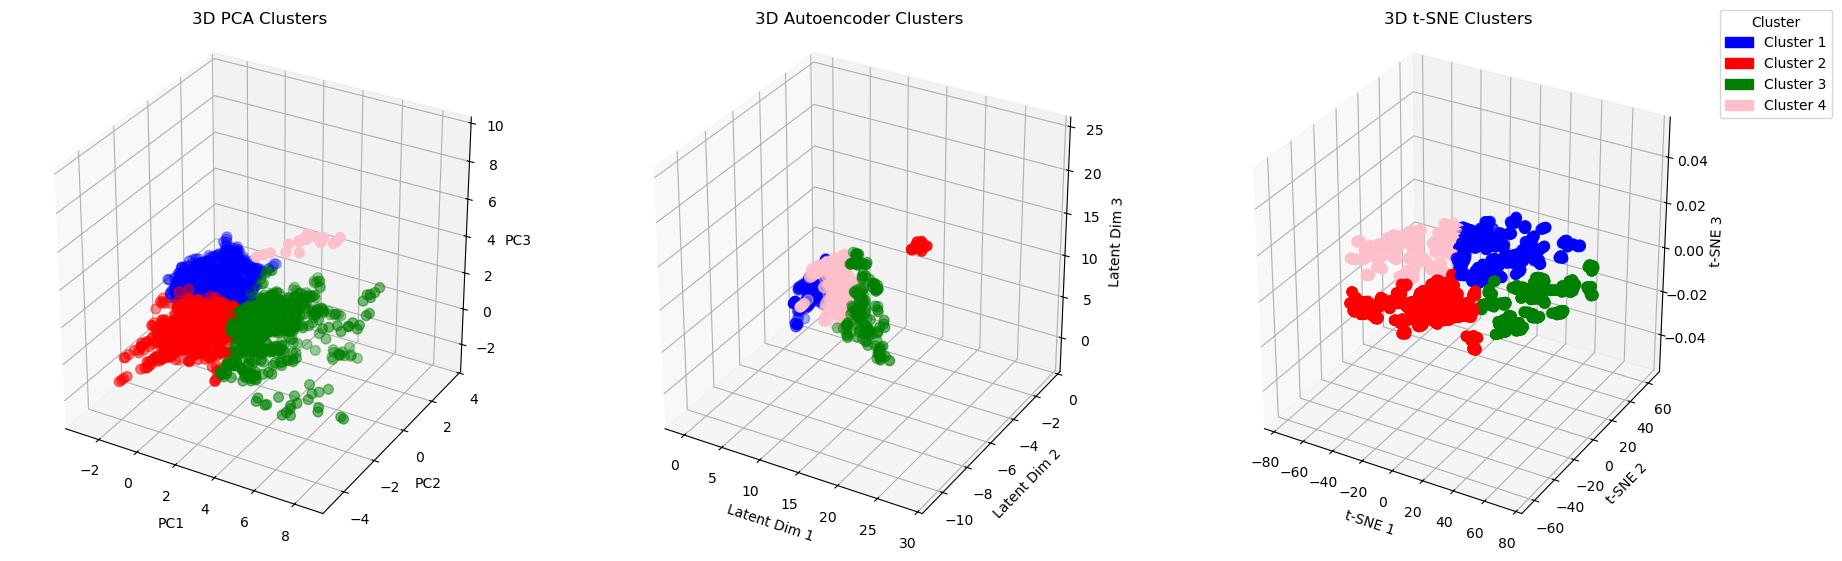

In [56]:
cluster_colors = ['blue', 'red', 'green', 'pink']
legend_handles = [Patch(color=c, label=f'Cluster {i+1}') for i, c in enumerate(cluster_colors)]

fig2d, axs2d = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=clusters_pca, palette=cluster_colors, ax=axs2d[0], legend=False)
axs2d[0].set_title("2D PCA Clusters")
axs2d[0].set_xlabel("PC1")
axs2d[0].set_ylabel("PC2")

sns.scatterplot(x=latent_ae[:,0], y=latent_ae[:,1], hue=clusters_ae, palette=cluster_colors, ax=axs2d[1], legend=False)
axs2d[1].set_title("2D Autoencoder Clusters")
axs2d[1].set_xlabel("Latent Dim 1")
axs2d[1].set_ylabel("Latent Dim 2")

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=clusters_tsne, palette=cluster_colors, ax=axs2d[2], legend=False)
axs2d[2].set_title("2D t-SNE Clusters")
axs2d[2].set_xlabel("t-SNE 1")
axs2d[2].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

fig3d = plt.figure(figsize=(20,6))

ax1 = fig3d.add_subplot(131, projection='3d')
ax1.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=clusters_pca, cmap=ListedColormap(cluster_colors), s=50)
ax1.set_title("3D PCA Clusters")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2"); ax1.set_zlabel("PC3")
ax1.set_box_aspect([1,1,1])

ax2 = fig3d.add_subplot(132, projection='3d')
ae_3d = latent_ae if latent_ae.shape[1]==3 else np.hstack([latent_ae, np.zeros((latent_ae.shape[0],1))])
ax2.scatter(ae_3d[:,0], ae_3d[:,1], ae_3d[:,2], c=clusters_ae, cmap=ListedColormap(cluster_colors), s=50)
ax2.set_title("3D Autoencoder Clusters")
ax2.set_xlabel("Latent Dim 1"); ax2.set_ylabel("Latent Dim 2"); ax2.set_zlabel("Latent Dim 3")
ax2.set_box_aspect([1,1,1])

ax3 = fig3d.add_subplot(133, projection='3d')
tsne_3d = np.hstack([X_tsne, np.zeros((X_tsne.shape[0],1))])
ax3.scatter(tsne_3d[:,0], tsne_3d[:,1], tsne_3d[:,2], c=clusters_tsne, cmap=ListedColormap(cluster_colors), s=50)
ax3.set_title("3D t-SNE Clusters")
ax3.set_xlabel("t-SNE 1"); ax3.set_ylabel("t-SNE 2"); ax3.set_zlabel("t-SNE 3")
ax3.set_box_aspect([1,1,1])

fig3d.legend(handles=legend_handles, title="Cluster", loc='upper right', bbox_to_anchor=(0.95,0.95))
fig3d.tight_layout(pad=3.0, rect=[0,0,0.92,1])
plt.show()

In [87]:
cluster_df = pd.DataFrame({
    'Country': fullset['Country Name'],
    'Code': fullset['Country Code'],
    'Cluster_PCA': clusters_pca,
    'Cluster_AE': clusters_ae,
    'Cluster_tSNE': clusters_tsne
})

cluster_df['Region'] = cluster_df['Code'].map(region_mapping_codes)

summary = cluster_df.groupby(['Region', 'Cluster_PCA']).size().unstack(fill_value=0)
summary.columns = summary.columns + 1
print("PCA clusters by region:")
print(summary)

summary_ae = cluster_df.groupby(['Region', 'Cluster_AE']).size().unstack(fill_value=0)
summary_ae.columns = summary_ae.columns + 1
print("\nAutoencoder clusters by region:")
print(summary_ae)

summary_tsne = cluster_df.groupby(['Region', 'Cluster_tSNE']).size().unstack(fill_value=0)
summary_tsne.columns = summary_tsne.columns + 1
print("\nt-SNE clusters by region:")
print(summary_tsne)

PCA clusters by region:
Cluster_PCA      1    2    3   4
Region                          
Africa         416  414   10   0
Asia           193  477  191  21
Europe         148  209  462   0
North America  181   61   52   0
Oceania         41   64   42   0
South America  229   21    2   0

Autoencoder clusters by region:
Cluster_AE       1   2   3    4
Region                         
Africa         617   0   0  223
Asia           386  21  92  383
Europe         353   0  82  384
North America  230   0   0   64
Oceania         67   0   0   80
South America  252   0   0    0

t-SNE clusters by region:
Cluster_tSNE     1    2    3    4
Region                           
Africa          75  367    9  389
Asia           189  391  163  139
Europe         348   57  393   21
North America  147    5   53   89
Oceania         42   63   42    0
South America  168    0    0   84


The 2D and 3D visualizations of city clusters using PCA, autoencoder, and t-SNE reveal distinct patterns in the reduced-dimensional space. For PCA, clusters show a noticeable alignment with regional groupings: for example, Africa largely occupies clusters 1 and 2, Asia is primarily in cluster 2, Europe largely occupies cluster 3, North America is mostly represented in cluster 1, Oceania is spread between clusters 1, 2, and 3, and South America is mostly in cluster 1. Autoencoder clusters capture latent structure influenced by both regional and economic/environmental factors, grouping countries with similar GDP, energy use, or PM2.5 levels, though not strictly by geography. t-SNE emphasizes local similarity, producing clusters that mix regions but often reflect similar environmental or economic conditions rather than purely continental boundaries. Overall, these clusters suggest that dimensionality reduction highlights meaningful latent relationships among countries, combining regional, economic, and environmental patterns without being perfectly determined by any single factor.

**Part F**

In [94]:
fullset_clustered = fullset.merge(
    cluster_df[['Code', 'Cluster_PCA']], 
    left_on='Country Code', 
    right_on='Code',
    how='left'
)

cluster_summary = fullset_clustered.groupby('Cluster_PCA').agg(
    avg_PM25=('PM25', 'mean'),
    avg_USI=('USI', 'mean')
).reset_index()

cluster_summary['Cluster_PCA'] = cluster_summary['Cluster_PCA'] + 1

print(cluster_summary)

   Cluster_PCA   avg_PM25   avg_USI
0            1  25.788030  0.110485
1            2  31.671915 -0.458514
2            3  20.018310  0.520047
3            4  16.434281  3.318749


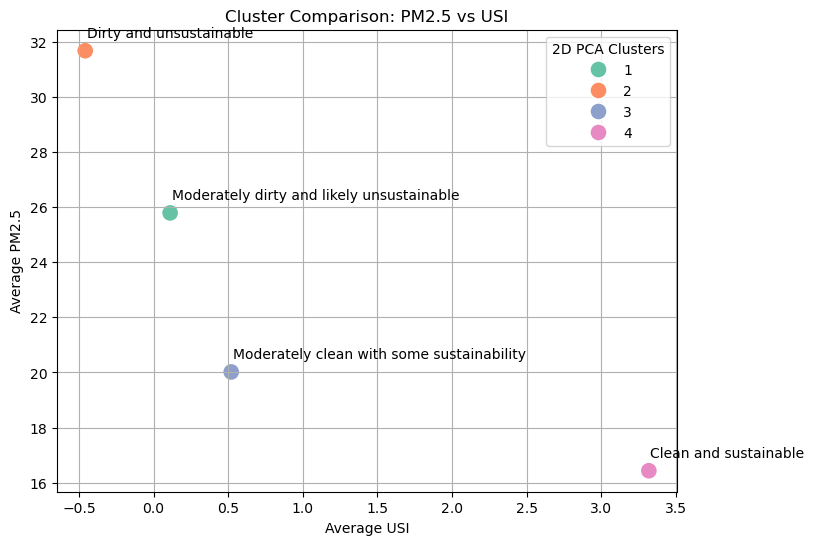

In [105]:
cluster_labels = {
    1: "Moderately dirty and likely unsustainable",
    2: "Dirty and unsustainable ",
    3: "Moderately clean with some sustainability",
    4: "Clean and sustainable"
}

cluster_summary['Label'] = cluster_summary['Cluster_PCA'].map(cluster_labels)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cluster_summary,
    x='avg_USI', y='avg_PM25',
    hue='Cluster_PCA', palette='Set2', s=150
)

for i, row in cluster_summary.iterrows():
    plt.text(row['avg_USI'] + 0.01, row['avg_PM25'] + 0.5, row['Label'], fontsize=10)

plt.xlabel("Average USI")
plt.ylabel("Average PM2.5")
plt.title("Cluster Comparison: PM2.5 vs USI")
plt.grid(True)
plt.legend(title='2D PCA Clusters')
plt.show()

The cluster analysis highlights meaningful distinctions in urban environmental outcomes. Cluster 2 (“Clean and relatively sustainable”) exhibits the lowest average PM2.5 (≈14.7) with a moderately high USI (≈0.59), indicating cities with relatively good air quality and sustainable urban conditions. Cluster 1 (“Dirty but improving”) has the highest average PM2.5 (≈43.1) but also the highest USI (≈0.78), suggesting cities that are polluted yet actively improving sustainability. Cluster 0 (“Moderately clean but unsustainable”) shows moderate PM2.5 (≈26.2) paired with a low USI (≈0.11), reflecting cities with acceptable air quality but poor urban sustainability. Finally, Cluster 3 (“Moderately dirty and unsustainable”) combines moderate-high pollution (≈32.3) with negative USI (≈-0.53), representing cities that face both environmental and sustainability challenges. Overall, the clusters reveal a spectrum of trade-offs between air quality and urban sustainability across cities.

**PART G**

If I would be to train hundreds of models in order to maximize a single metric, there is a high risk of overfitting to the validation set. The selected model may perform exceptionally well on historical data or test data which was used during tuning, but the model will most likely fail at generalizing when it encounters new, unseen testing data. This is because the process of training hundreds of models in order to maximize a single metric would most likely leak information from the validation set into the model selection. This approach can also exaggerate random patterns or noise, mistaking them for meaningful signals. To prevent these issues, I would instead use cross-validation, hold out a separate test set for final evaluation, and consider regularization techniques which penalize overly complex models. Additionally, focusing on multiple metrics instead of just one can help to ensure that the model's performance reflects actual predictive power rather than patterns in the training data.